In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
import shap
import shap
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv(r"C:\Users\admin\Documents\python\heart.csv")
#df

In [46]:
#df.isna().sum()
#df.info()
#df.describe()
df.replace('-', np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

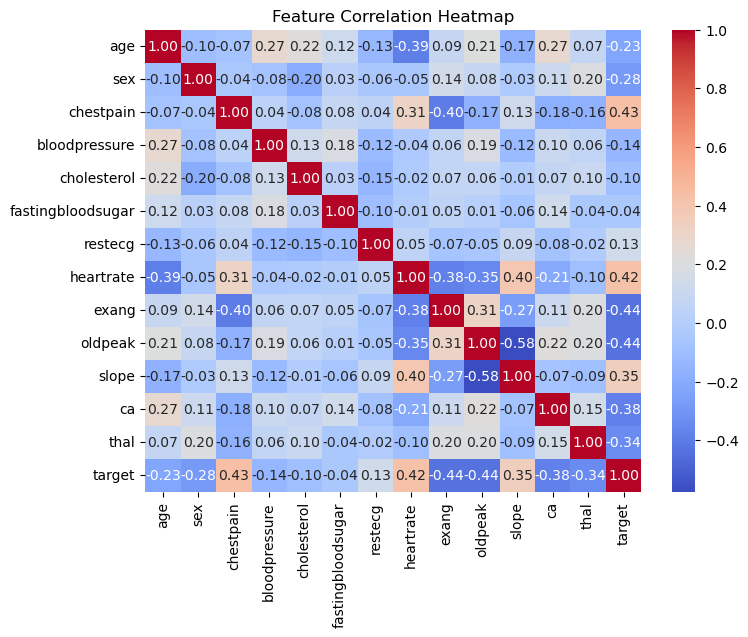

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

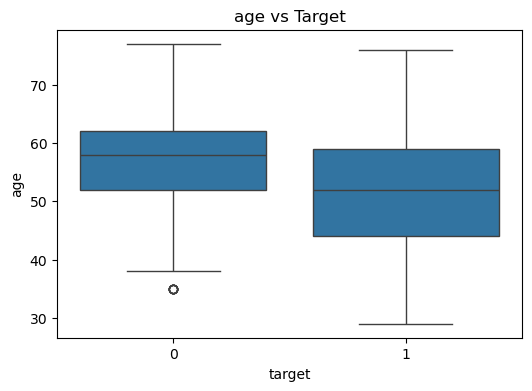

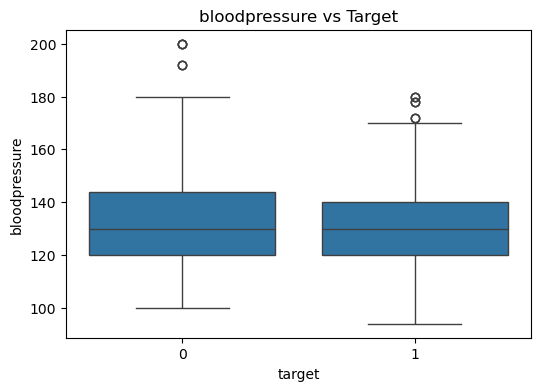

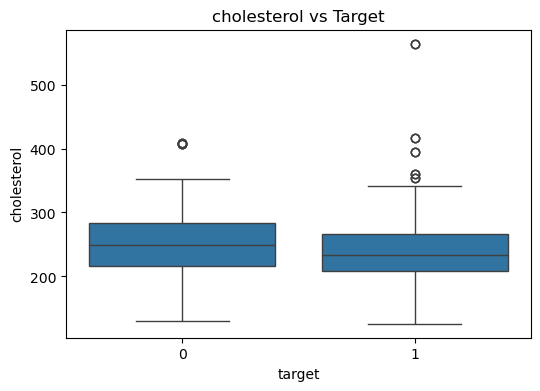

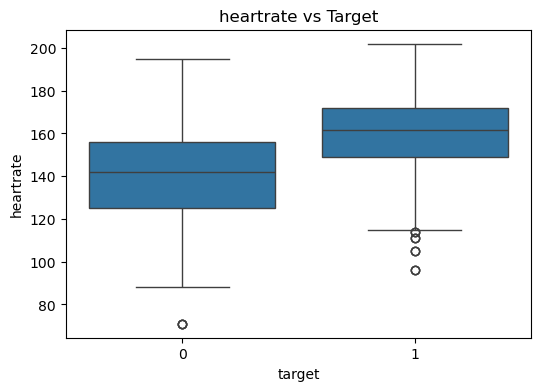

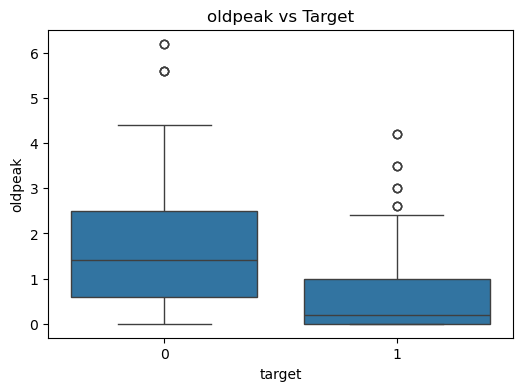

In [48]:
num_cols = ["age", "bloodpressure", "cholesterol", "heartrate", "oldpeak"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

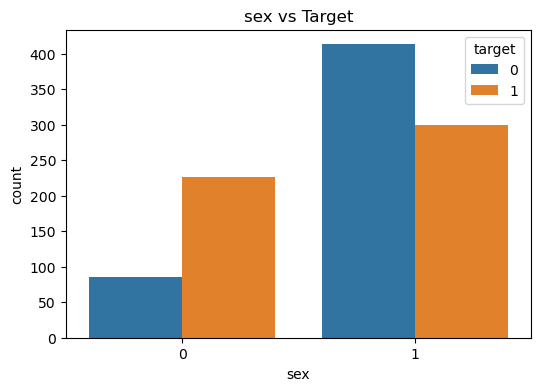

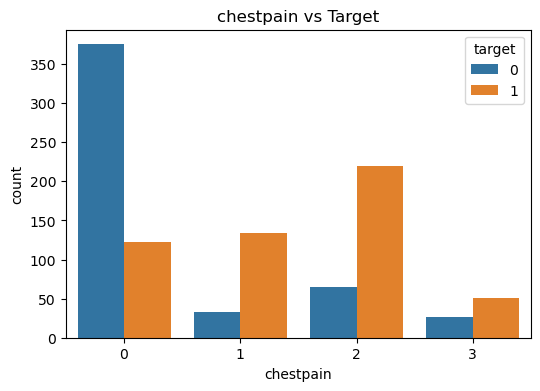

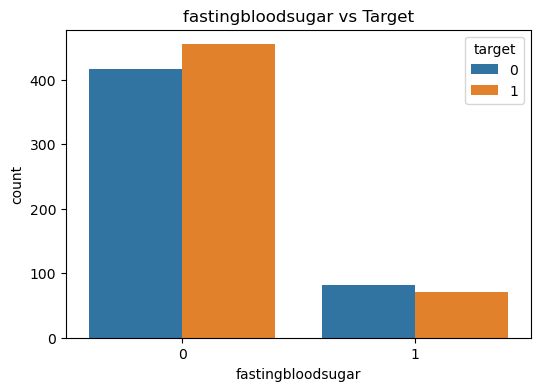

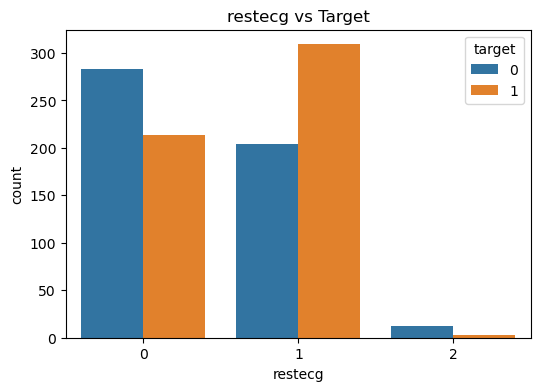

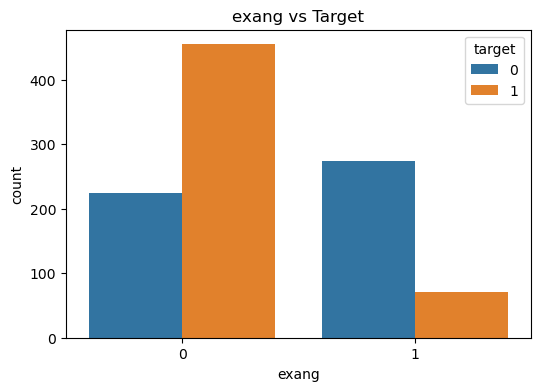

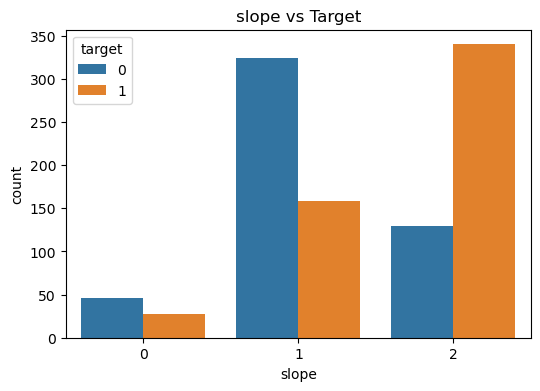

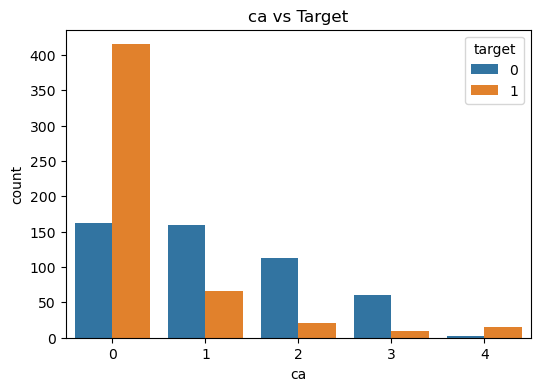

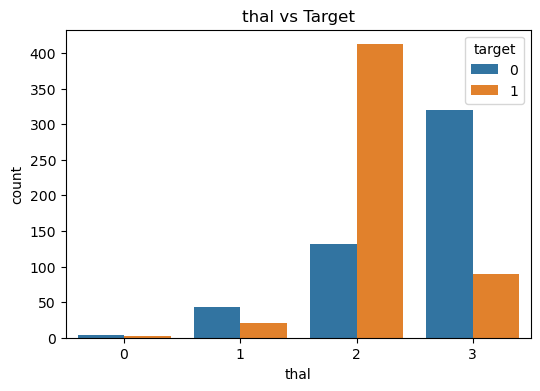

In [49]:
cat_cols = ["sex", "chestpain", "fastingbloodsugar", "restecg", "exang", "slope", "ca", "thal"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="target", data=df)
    plt.title(f"{col} vs Target")
    plt.show()

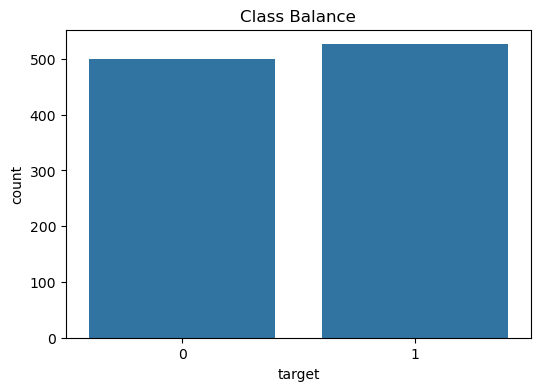

In [50]:
# 1. Check class balance — very important
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Class Balance")
plt.show()


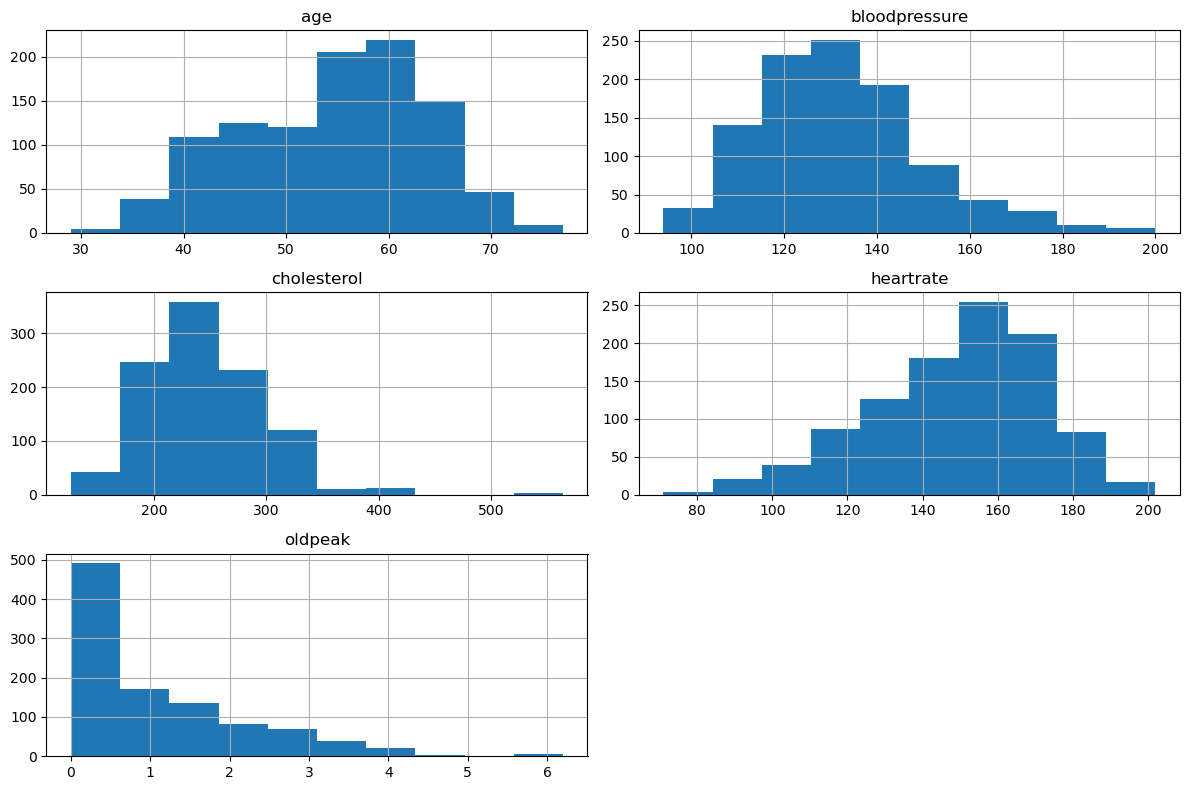

In [51]:
# 2. Distribution of numerical features

df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

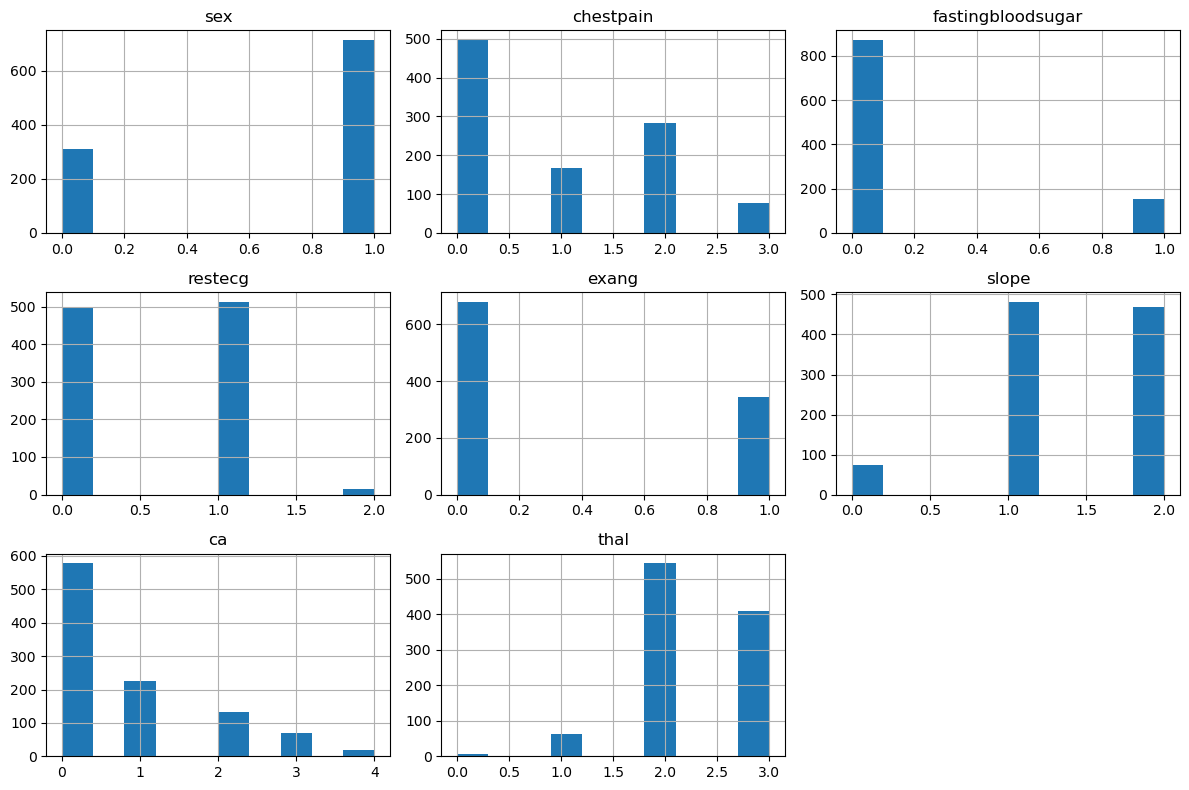

In [52]:
df[cat_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [89]:
#split data and 
x = df.drop("target", axis=1)
y = df["target"]
#train test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
#creating trnasformers
num_cols = ["age", "bloodpressure", "cholesterol", "heartrate", "oldpeak"]

cat_cols = ["sex", "chestpain", "fastingbloodsugar", 
            "restecg", "exang", "slope", "ca", "thal"]
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_cols)
])

In [54]:
#pipelines
log_pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000))])
dt_pipeline  = Pipeline([("preprocessor", preprocessor), ("model", DecisionTreeClassifier(random_state=42))])
nb_pipeline  = Pipeline([("preprocessor", preprocessor), ("model", GaussianNB())])


In [55]:


print("LR CV:  ", cross_val_score(log_pipeline, x, y, cv=5).mean())
print("DT CV:  ", cross_val_score(dt_pipeline,  x, y, cv=5).mean())
print("NB CV:  ", cross_val_score(nb_pipeline,  x, y, cv=5).mean())

LR CV:   0.8614634146341464
DT CV:   0.9882926829268293
NB CV:   0.8341463414634147


In [56]:
param_grid = {"model__C": [0.1, 1, 10]}
grid = GridSearchCV(log_pipeline, param_grid, cv=5)
grid.fit(x_train, y_train)
print("Best C:", grid.best_params_)


C:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best C: {'model__C': 1}


In [57]:
log_pipeline.fit(x_train, y_train)
dt_pipeline.fit(x_train, y_train)
nb_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
#decison tree cross
cross_val_score(dt_pipeline, x, y, cv=5)

array([1.        , 1.        , 0.98536585, 0.97073171, 0.98536585])

In [59]:
#naive bayes cross
cross_val_score(nb_pipeline, x, y, cv=5)

array([0.84878049, 0.85365854, 0.84878049, 0.8195122 , 0.8       ])

In [60]:


dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [61]:


nb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])
OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [62]:
#train the models
log_pipeline.fit(x_train, y_train)
dt_pipeline.fit(x_train, y_train)
nb_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
results =[]
models = {
    "Logistic Regression": log_pipeline,
    "Decision Tree": dt_pipeline,
    "Naive Bayes": nb_pipeline
}
for name, model in models.items():
    y_pred = model.predict(x_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.819512   0.779661  0.893204  0.832579
1        Decision Tree  1.000000   1.000000  1.000000  1.000000
2          Naive Bayes  0.804878   0.769231  0.873786  0.818182


In [ ]:
#Model  Accuracy  Precision    Recall        F1
#0  Logistic Regression  0.819512   0.779661  0.893204  0.832579 

In [91]:
opt_results.columns

Index(['age', 'sex', 'chestpain', 'bloodpressure', 'cholesterol',
       'fastingbloodsugar', 'restecg', 'heartrate', 'exang', 'oldpeak',
       'slope', 'ca', 'thal', 'prediction'],
      dtype='object')

 Volume in drive C has no label.
 Volume Serial Number is 647F-C3D9

 Directory of C:\Users\admin

04/27/2026  06:55 PM    <DIR>          .
04/27/2026  06:55 PM    <DIR>          ..
02/26/2026  01:05 PM    <DIR>          .anaconda
04/22/2026  06:00 PM               769 .bash_history
02/26/2026  01:24 PM    <DIR>          .conda
02/26/2026  01:20 PM    <DIR>          .continuum
04/01/2026  12:58 AM                53 .gitconfig
04/24/2026  05:32 PM    <DIR>          .ipynb_checkpoints
02/23/2026  01:45 PM    <DIR>          .ipython
03/17/2026  12:40 PM    <DIR>          .junie
04/02/2026  06:34 PM    <DIR>          .jupyter
02/23/2026  01:45 PM    <DIR>          .matplotlib
04/20/2026  05:19 PM    <DIR>          .spyder-py3
03/22/2025  03:30 PM    <DIR>          .THypervBox
04/01/2026  01:13 AM               988 .viminfo
08/02/2024  06:46 PM    <DIR>          .vscode
03/05/2026  02:52 PM             4,890 1 hour before yet to set.ipynb
02/27/2026  07:29 PM               517 3 by 3.py
03/

In [94]:
opt_results = x_test.copy()
opt_results["target"] = y_test.to_list()
opt_results["prediction"] = y_pred
opt_results['confusion_matrix_type'] = np.where(
    (opt_results['target'] == 1) & (opt_results['prediction'] == 1), 'TP',
    np.where(
        (opt_results['target'] == 0) & (opt_results['prediction'] == 0), 'TN',
        np.where(
            (opt_results['target'] == 0) & (opt_results['prediction'] == 1), 'FP',
            'FN'
        )
    )
)
opt_results.to_excel("heart_disease_results.xlsx", index=False)


<Axes: >

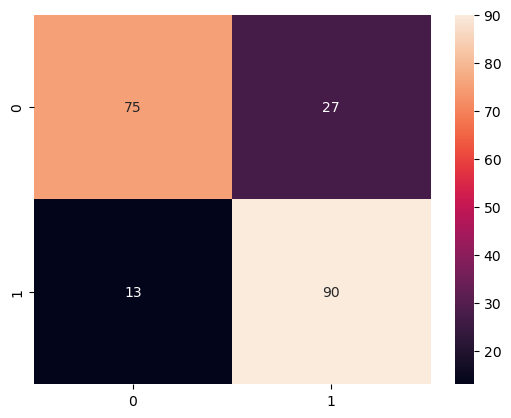

In [64]:
# 3. Confusion matrix heatmap — per model
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")

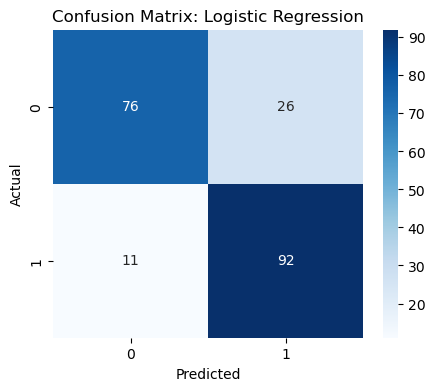

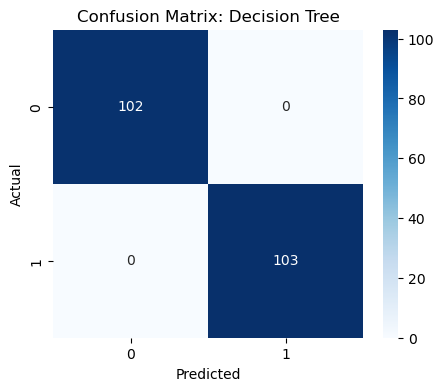

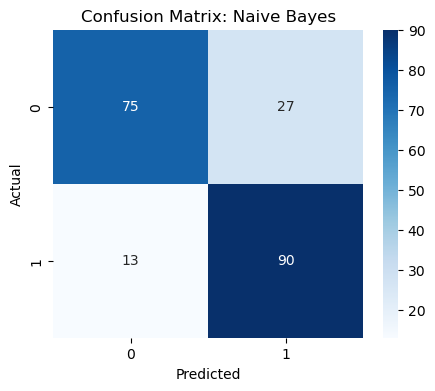

In [65]:
for name, model in models.items():
    y_pred = model.predict(x_test)
    
    
    
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

#Top left: Actuall healthy + predicted healthy = corrects =True Negative  //Recall
#Bottom right: Actually sick + predicted sich = true positive   
#Top right: actually healthy + predicted sick = false positive
#bottom left :Acutaly sick + predicted healthy= False Negatove
#

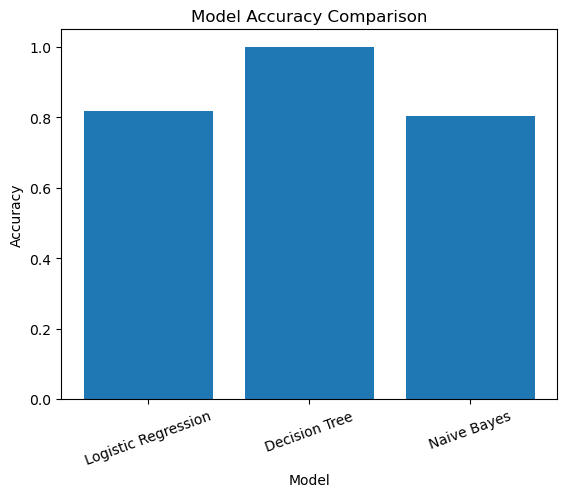

In [66]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

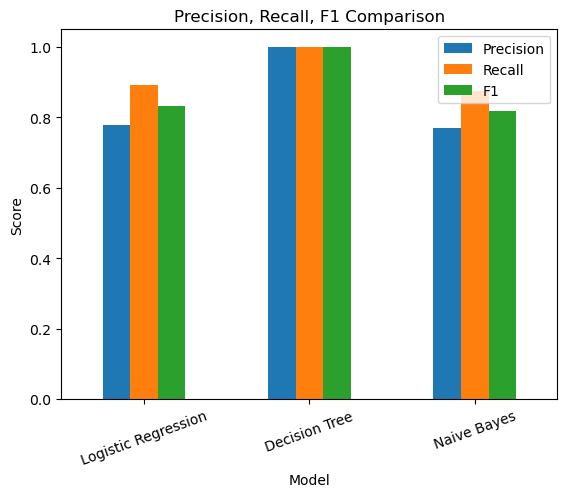

In [67]:
results_df.set_index("Model")[["Precision", "Recall", "F1"]].plot(kind="bar")
plt.title("Precision, Recall, F1 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

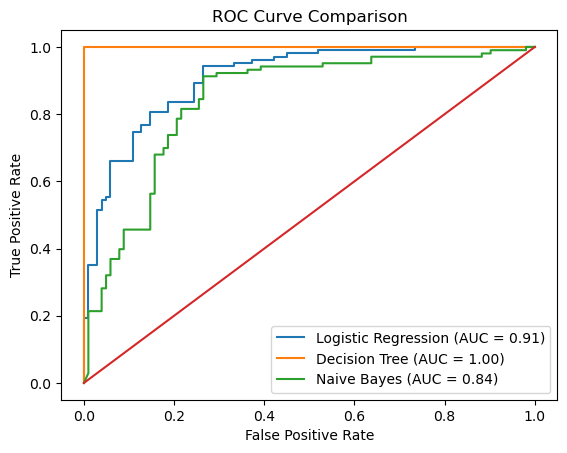

In [68]:
plt.figure()

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1], [0,1])  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

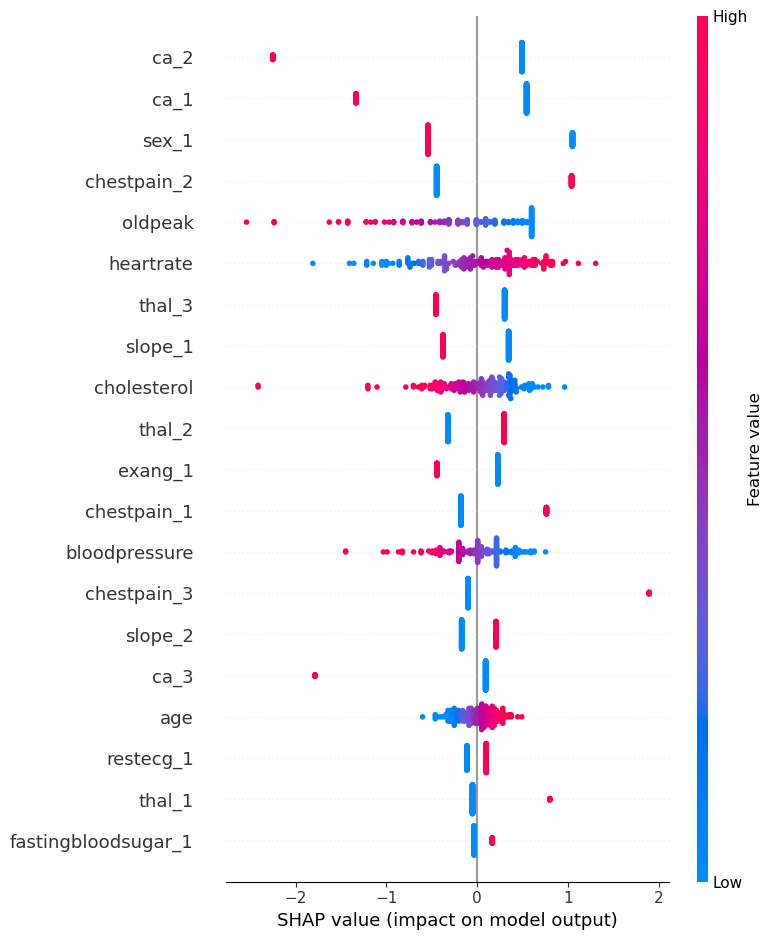

In [85]:
#shap
best_model = log_pipeline
feature_names = log_pipeline.named_steps["preprocessor"].get_feature_names_out()
x_test_processed = log_pipeline.named_steps["preprocessor"].transform(x_test)
shap_values = explainer(x_test_processed)
explainer = shap.LinearExplainer(
    log_pipeline.named_steps["model"],
    x_test_processed
)
shap_df = pd.DataFrame(
    shap_values.values,
    columns=feature_names
)
#shap_values = explainer(x_test_processed)


clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]
shap.summary_plot(shap_values, x_test_processed, feature_names=clean_names)

In [72]:
shap_df = pd.DataFrame(
    shap_values.values,
    columns=clean_names
)

In [83]:
#shap.plots.bar(shap_values)

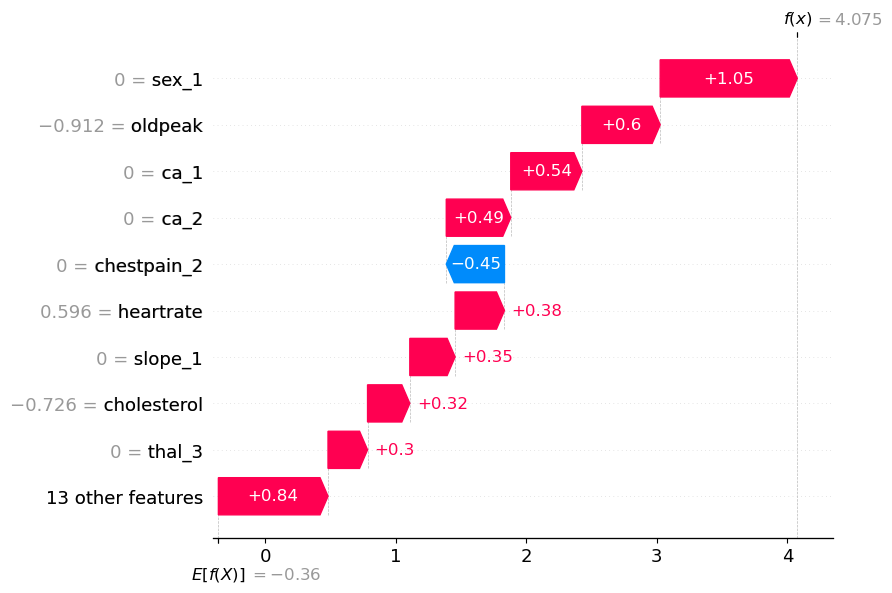

In [74]:
#patient who has increasing rate of heart disease
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[0],
        base_values=shap_values.base_values[0],
        data=x_test_processed[0],
        feature_names=clean_names
    )
)

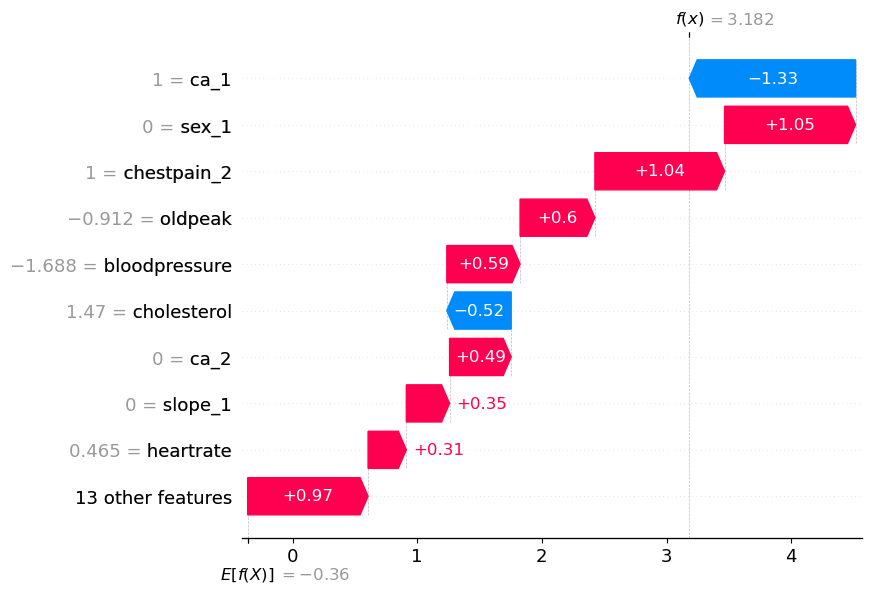

In [75]:
#patient who is healthy
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values.values[10],
        base_values=shap_values.base_values[10],
        data=x_test_processed[10],
        feature_names=clean_names
    )
)

In [76]:
final_shap_df = pd.concat(
    [pd.DataFrame(x_test_processed, columns=shap_df.columns), shap_df],
    axis=1
)

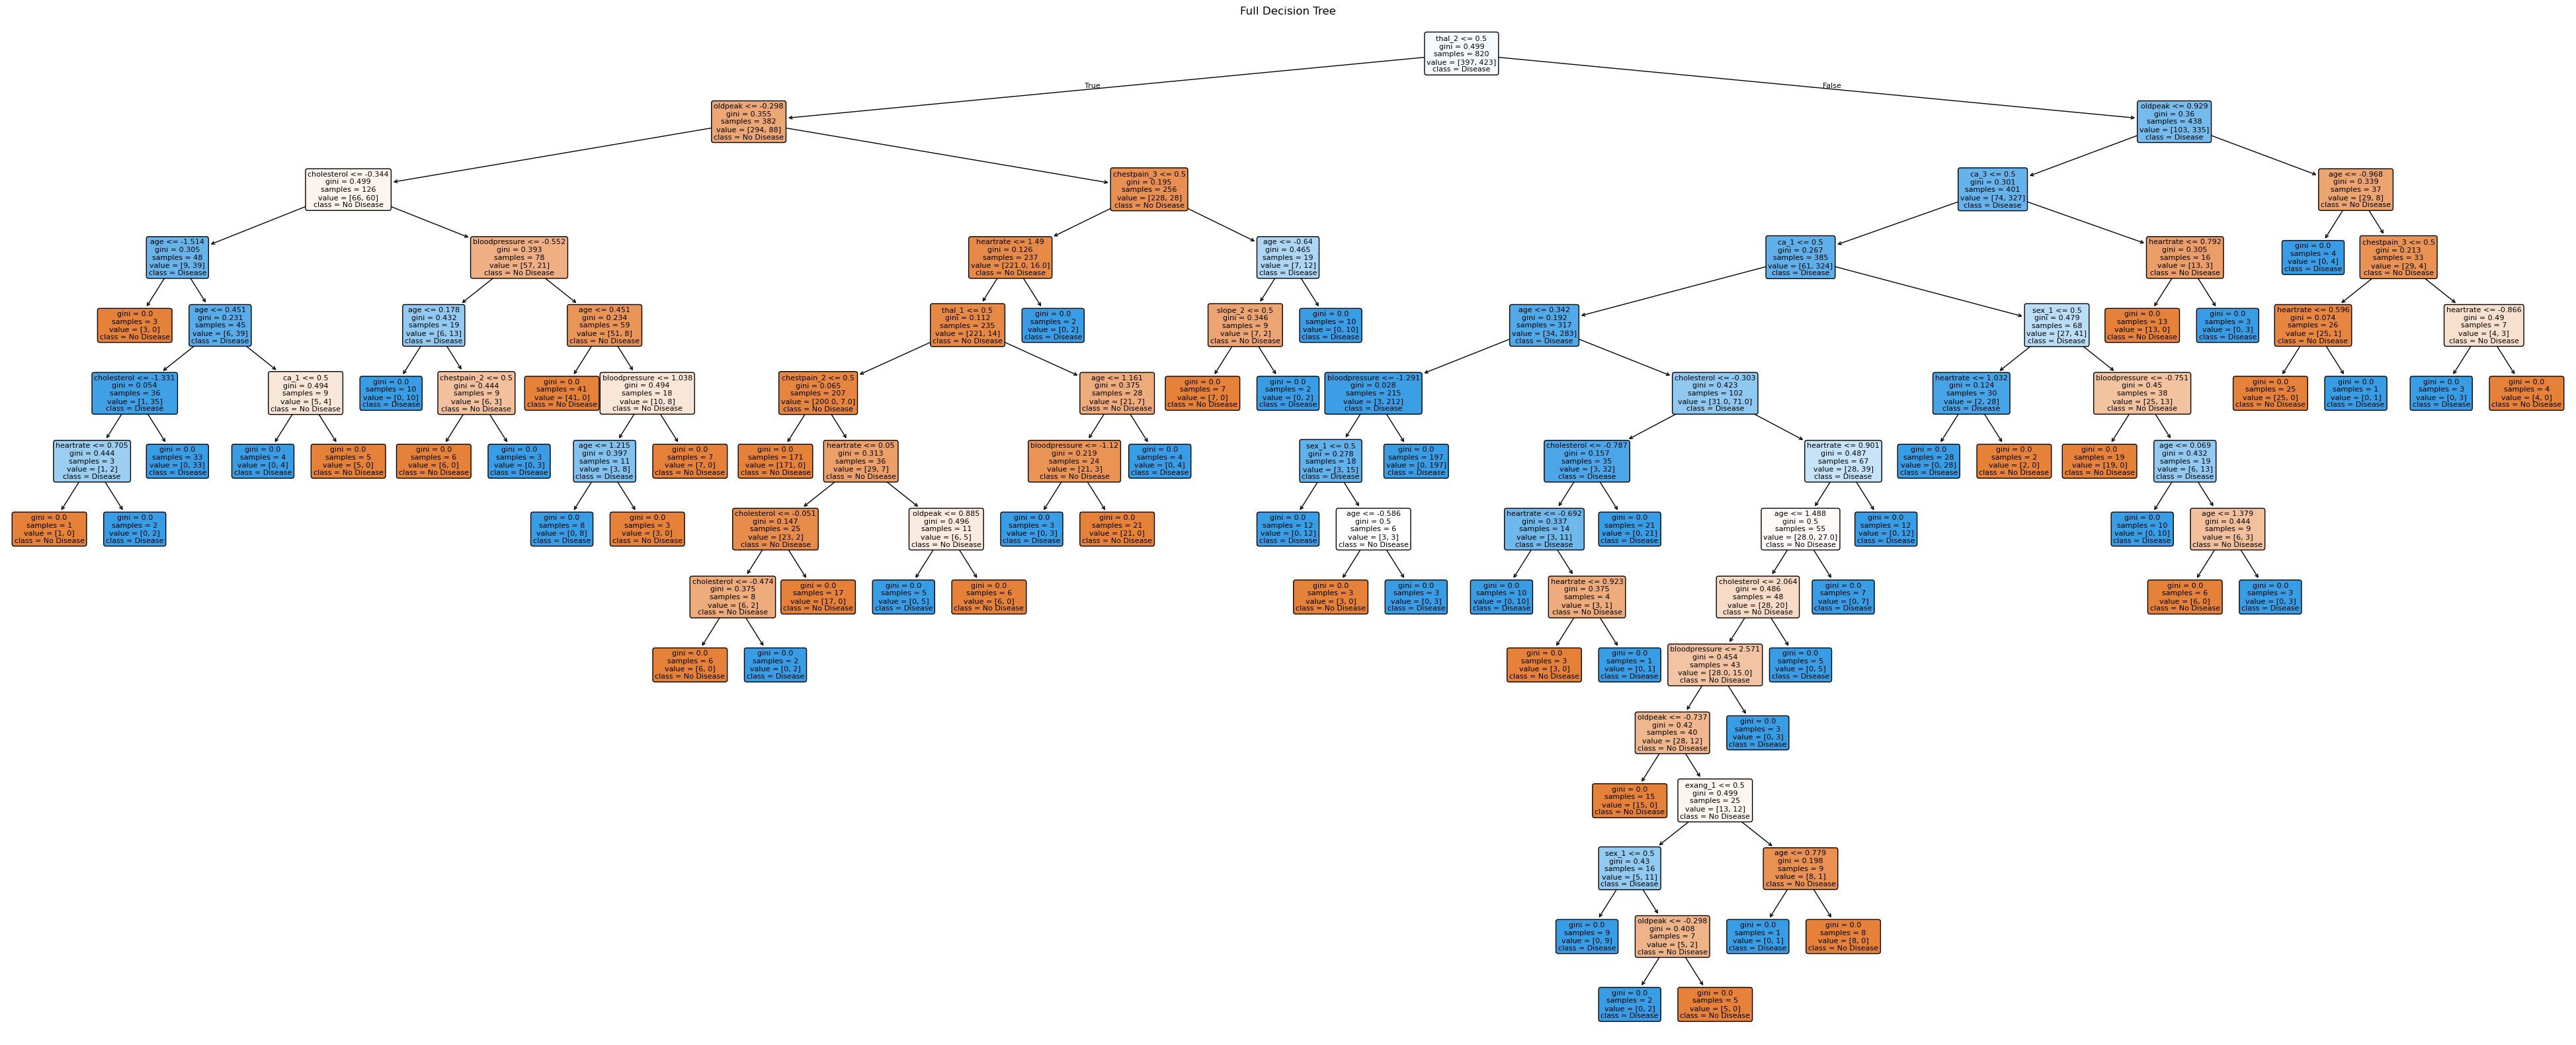

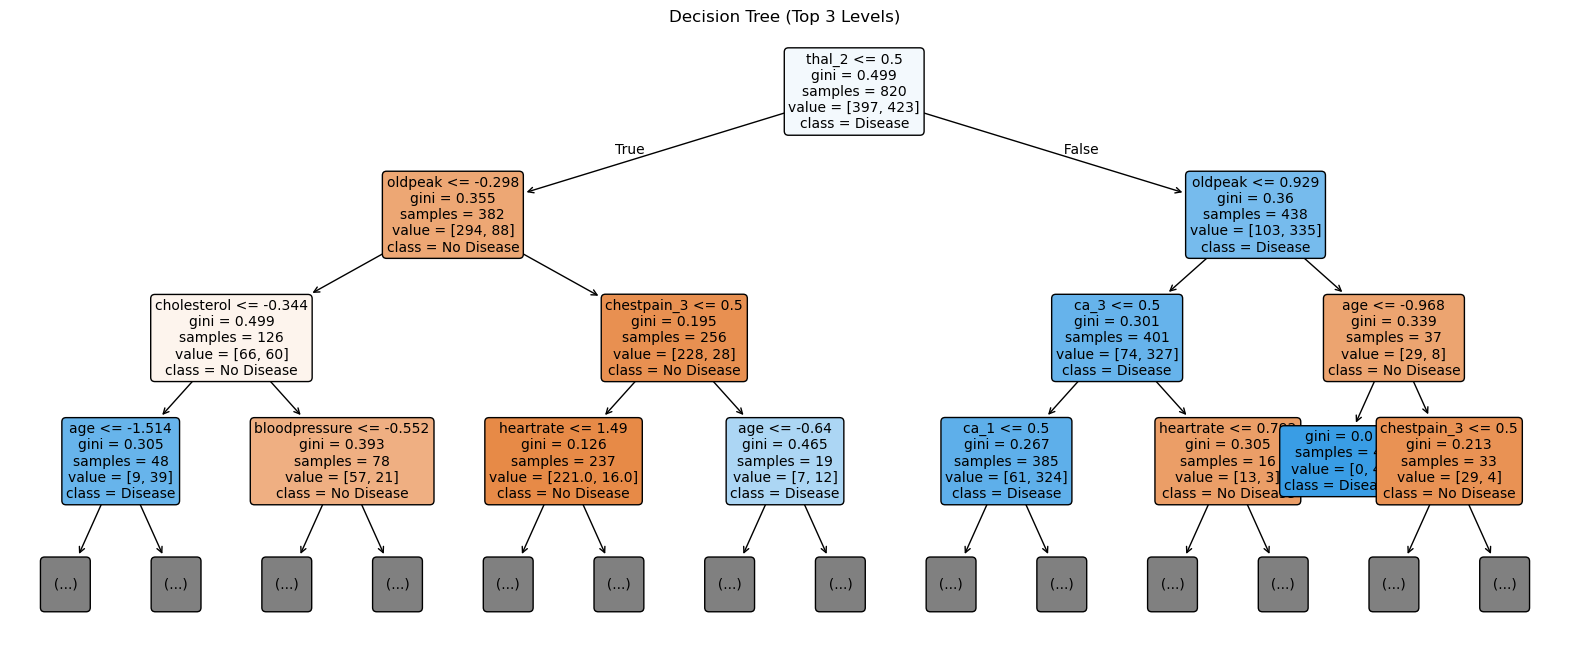

C:\Users\admin\AppData\Local\Temp\ipykernel_11640\942853529.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="coolwarm")


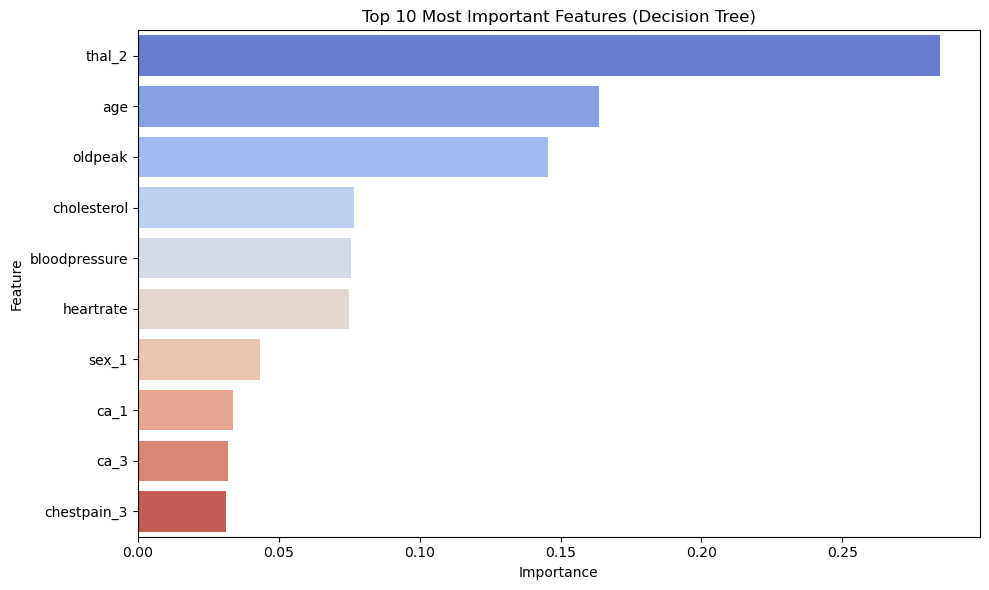

|--- thal_2 <= 0.50
|   |--- oldpeak <= -0.30
|   |   |--- cholesterol <= -0.34
|   |   |   |--- age <= -1.51
|   |   |   |   |--- class: 0
|   |   |   |--- age >  -1.51
|   |   |   |   |--- age <= 0.45
|   |   |   |   |   |--- cholesterol <= -1.33
|   |   |   |   |   |   |--- heartrate <= 0.70
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- heartrate >  0.70
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- cholesterol >  -1.33
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  0.45
|   |   |   |   |   |--- ca_1 <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- ca_1 >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- cholesterol >  -0.34
|   |   |   |--- bloodpressure <= -0.55
|   |   |   |   |--- age <= 0.18
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  0.18
|   |   |   |   |   |--- chestpain_2 <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- chestpain_2 >  0.50
| 

In [82]:
from sklearn.tree import plot_tree

# Get the trained Decision Tree model from pipeline
dt_model = dt_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()
clean_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# ── 1. Full Tree ──────────────────────────────────────────
plt.figure(figsize=(50, 20))
plot_tree(
    dt_model,
    feature_names=clean_names,
    class_names=["No Disease", "Disease"],
    filled=True,        # color nodes by class
    rounded=True,       # rounded boxes
    fontsize=8
)
plt.title("Full Decision Tree")
plt.show()

# ── 2. Simplified Tree (max depth=3, easier to read) ──────
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=clean_names,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3        
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()

# ── 3. Feature Importance Bar Chart ───────────────────────
importances = dt_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": clean_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="coolwarm")
plt.title("Top 10 Most Important Features (Decision Tree)")
plt.tight_layout()
plt.show()

# ── 4. Text representation (good for viva explanation) ────
from sklearn.tree import export_text
tree_text = export_text(dt_model, feature_names=clean_names)
print(tree_text)

In [79]:
# 1. Get the processed data and feature names
x_test_proc = log_pipeline.named_steps["preprocessor"].transform(x_test)
feature_names = log_pipeline.named_steps["preprocessor"].get_feature_names_out()
final_results = x_test.reset_index(drop=True).copy()
# 2. Get the model coefficients (the weights)
weights = log_pipeline.named_steps["model"].coef_[0]

# 3. Calculate individual contributions (Data * Weight)
contributions = x_test_proc * weights

# 4. Find the 'Top Driver' for each patient
# This looks at which column had the biggest impact
top_feature_idx = np.argmax(np.abs(contributions), axis=1)
top_feature_names = [feature_names[i] for i in top_feature_idx]

# 5. Calculate the percentage impact of the top feature
total_impact = np.sum(np.abs(contributions), axis=1)
top_feature_impact = np.abs(contributions[np.arange(len(contributions)), top_feature_idx])
percentage_contribution = (top_feature_impact / total_impact) * 100

# 6. Add to your results dataframe
final_results['Primary_Risk_Factor'] = top_feature_names
final_results['Factor_Contribution_Percentage'] = np.round(percentage_contribution, 2)

# Save the updated file
final_results.to_csv('documents\heart_disease_detailed_analysis.csv', index=False)
print("Updated CSV with Contribution Percentages created!")

Updated CSV with Contribution Percentages created!


In [80]:
# 1. Get the processed numbers (what the model actually 'sees')
x_test_proc = log_pipeline.named_steps["preprocessor"].transform(x_test)
feature_names = log_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 2. Get the model's weights (Coefficients)
weights = log_pipeline.named_steps["model"].coef_[0]

# 3. Calculate 'Importance Points' for every cell (Data * Weight)
# This shows how much each specific value pushed the needle
contributions = x_test_proc * weights

# 4. Calculate total absolute impact for each patient
total_abs_impact = np.sum(np.abs(contributions), axis=1)

# 5. Create a DataFrame for these percentages
# We divide each feature's impact by the total impact of all features
contribution_pct_df = pd.DataFrame(
    (np.abs(contributions) / total_abs_impact[:, None]) * 100,
    columns=[f"{col}_Contribution_%" for col in feature_names]
)

# 6. Combine everything into your final CSV
final_detailed_df = pd.concat([
    x_test.reset_index(drop=True), 
    pd.Series(y_test.values, name='Real_Target'),
    pd.Series(log_pipeline.predict(x_test), name='Predicted_Target'),
    pd.Series(log_pipeline.predict_proba(x_test)[:, 1], name='Disease_Probability'),
    contribution_pct_df
], axis=1)

# Save to CSV
final_detailed_df.to_csv('documents\heart_disease_full_probability_report.csv', index=False)
print("Detailed Probability CSV Created!")

Detailed Probability CSV Created!
